# NLP Project: Fine-tuning Qwen 2.5 on Research Papers (PDFs)

**Pipeline Overview:**
1. Install dependencies & mount Google Drive
2. Ingest PDF research papers as the dataset
3. Load & configure the Phi 2 model with 4-bit quantization + LoRA
4. **Fine-tune using a manual PyTorch training loop** (replaces SFTTrainer — more stable on Colab T4)
5. Baseline comparison (DistilBERT on IMDB)
6. Evaluation & error metrics (Perplexity, Loss, Classification report, Confusion matrix)
7. Results comparison table & bar chart
8. Streamlit dashboard & Localtunnel

In [1]:
# !python.exe -m pip install --upgrade pip
# !pip install -U sentence-transformers
# !pip install ollama
# !pip install sentence-transformers
# !pip install chromadb
# !pip install pandas
# !pip install scikit-learn
# !pip install unsloth datasets trl

# RE TRAIN THE MODEL

### Step 2 — PDF Data Ingestion

Place your research paper PDFs in `MyDrive/NLP/` (or update `NLP_PDF_PATH` below).

In [1]:
import os
import fitz
from datasets import Dataset

PDF_PATH = './DatasetForAppliedNLPProject'

def load_pdfs(folder_path):
    docs = []
    for file in sorted(os.listdir(folder_path)):
        if not file.endswith('.pdf'):
            continue
        try:
            with fitz.open(os.path.join(folder_path, file)) as doc:
                text = "".join(page.get_text() for page in doc).strip()
            docs.append({"text": text, "source": file})
            print(f"Loaded: {file} ({len(text):,} chars)")
        except Exception as e:
            print(f"Skipped: {file} — {e}")
    return docs

docs = load_pdfs(PDF_PATH)
dataset = Dataset.from_list(docs) if docs else None
print(f"\n{len(docs)} PDF(s) loaded." if docs else "\nNo PDFs found.")

Loaded: 16th_ICCCNT_2025_paper_8988.pdf (39,598 chars)
Loaded: 418_final+publish.pdf (47,584 chars)
Loaded: 87184.pdf (64,105 chars)
Loaded: Manuscript_SPeneauetal_reviewed_Freshness_BFJournal.pdf (48,979 chars)
Loaded: Pest Management Science - 2023 - Trippa - Next‐generation methods for early disease detection in crops.pdf (108,493 chars)
Loaded: agriculture-13-01810.pdf (83,968 chars)
Loaded: agronomy-14-00699.pdf (42,359 chars)
Loaded: foods-12-01830.pdf (17,769 chars)
Loaded: horticulturae-12-00357-v2.pdf (81,665 chars)
Loaded: ir5010_down.pdf (64,292 chars)
Loaded: journal.pone.0322586.pdf (76,913 chars)
Loaded: plants-12-03704.pdf (69,995 chars)
Loaded: plants-14-03569.pdf (88,842 chars)

13 PDF(s) loaded.


In [ ]:
# from datasets import Dataset

# def chunk_text(text, chunk_size=256, overlap=50):
#     words = text.split()
#     chunks = []
#     for i in range(0, len(words), chunk_size - overlap):
#         chunk = " ".join(words[i:i + chunk_size])
#         if chunk:
#             chunks.append(chunk)
#     return chunks

# # Replace your dataset creation with this
# chunked_docs = []
# for doc in docs:
#     for chunk in chunk_text(doc["text"]):
#         chunked_docs.append({"text": chunk, "source": doc["source"]})

# dataset = Dataset.from_list(chunked_docs)
# print(f"{len(docs)} PDFs → {len(chunked_docs)} chunks")

13 PDFs → 589 chunks


### Step 3 — Model Initialisation (Qwen 2.5 + 4-bit Quantization + LoRA)

> **Note on dtype:** Qwen 2.5 uses bfloat16 internally. We load with `bnb_4bit_compute_dtype=torch.float16`
> and disable AMP (`fp16=False`, `bf16=False`) in the training loop to avoid the
> `_amp_foreach_non_finite_check_and_unscale_cuda` error that breaks SFTTrainer on Colab T4.

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
LLM_MODEL = "microsoft/phi-2"

CUDA = torch.cuda.is_available()

# ── Hyperparameters ───────────────────────────────────────────────────────────
MAX_SEQ_LEN = 512
BATCH_SIZE  = 1
LR          = 1e-3
GRAD_ACCUM  = 4      # ↑ increased: smoother gradients with small dataset
MAX_STEPS   = 200     # ↓ reduced: 7 docs still small, avoid overfitting
LOG_EVERY   = 5
train_loss_history = []

# ── Models ────────────────────────────────────────────────────────────────────
embed_model = SentenceTransformer(EMBEDDING_MODEL)

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token

if CUDA:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL, quantization_config=bnb_config, device_map={"": 0}, trust_remote_code=True
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL, dtype=torch.float32, trust_remote_code=True
    )

model.config.pad_token_id = tokenizer.pad_token_id
model = prepare_model_for_kbit_training(model)

# ── LoRA config ───────────────────────────────────────────────────────────────
# r=4 ↓ reduced capacity to reduce overfitting on small dataset
# lora_alpha=8 follows 2x r rule
# lora_dropout=0.1 ↑ slightly more regularization
model = get_peft_model(model, LoraConfig(
    r=4, lora_alpha=8, lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    bias="none", task_type="CAUSAL_LM",
))
model.print_trainable_parameters()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

trainable params: 1,966,080 || all params: 2,781,649,920 || trainable%: 0.0707


### Step 4 — Fine-Tuning via Manual PyTorch Training Loop

We replace SFTTrainer with a plain PyTorch loop. This avoids:
- `NotImplementedError: _amp_foreach_non_finite_check_and_unscale_cuda` (BFloat16/fp16 AMP conflict)
- Tokenizer / `max_seq_length` attribute errors across TRL versions

Training loss is logged every `LOG_EVERY` steps and stored in `train_loss_history` for the comparison plot.

In [3]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from tqdm import tqdm
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

cuda


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): PhiForCausalLM(
      (model): PhiModel(
        (embed_tokens): Embedding(51200, 2560)
        (layers): ModuleList(
          (0-31): 32 x PhiDecoderLayer(
            (self_attn): PhiAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2560, out_features=2560, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=4, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=4, out_features=2560, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear4bit(

In [4]:
#make sure the model is globally accessible for the training loop
if 'model' not in globals():
    raise RuntimeError("Model is not defined. Run the model initialization cell first.")

In [5]:

class PDFTextDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len):
        self.rows = list(hf_dataset)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        prompt = f"### Research Paper ({row['source']}):\n{row['text']}"
        return {"text": prompt}

def collate_fn(batch):
    texts = [b["text"] for b in batch]
    enc = tokenizer(texts, truncation=True, padding=True, max_length=MAX_SEQ_LEN, return_tensors="pt")
    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]
    labels = input_ids.clone()
    labels[attention_mask == 0] = -100
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


In [6]:

# Change batch_size to match your tiny dataset
train_ds = PDFTextDataset(dataset, tokenizer, MAX_SEQ_LEN)

train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=False,
    num_workers=0,
    drop_last=False,
)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

model.train()
global_step = 0
accum_loss = 0.0

print(f"Starting fine-tuning — {MAX_STEPS} steps, batch={BATCH_SIZE}, grad_accum={GRAD_ACCUM}")
print(f"Dataset size: {len(train_ds)} samples")
# print("-" * 70)

# pbar = tqdm(total=MAX_STEPS, desc="Training", unit="step")
optimizer.zero_grad()

Starting fine-tuning — 200 steps, batch=1, grad_accum=4
Dataset size: 13 samples


In [7]:
# Add this BEFORE the training loop to verify DataLoader works
print("Testing DataLoader...")
test_batch = next(iter(train_dl))
print(f"✓ Batch loaded successfully!")
print(f"  Input shape: {test_batch['input_ids'].shape}")
print(f"  Attention mask shape: {test_batch['attention_mask'].shape}")
print(f"  Labels shape: {test_batch['labels'].shape}")
print("-" * 70)

Testing DataLoader...
✓ Batch loaded successfully!
  Input shape: torch.Size([1, 512])
  Attention mask shape: torch.Size([1, 512])
  Labels shape: torch.Size([1, 512])
----------------------------------------------------------------------


In [8]:
from itertools import cycle

PATIENCE = 40        # stop if no improvement for this many steps
MIN_DELTA = 1e-2     # minimum improvement to count
MAX_GRAD_NORM = 1.0  # clip gradients if norm exceeds this

train_cycle = cycle(train_dl)
model.train()
optimizer.zero_grad(set_to_none=True)

best_loss = float('inf')
no_improve = 0

for step in range(1, MAX_STEPS + 1):
    for micro in range(GRAD_ACCUM):
        batch = next(train_cycle)
        input_ids      = batch["input_ids"].to(device, non_blocking=CUDA)
        attention_mask = batch["attention_mask"].to(device, non_blocking=CUDA)
        labels         = batch["labels"].to(device, non_blocking=CUDA)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss / GRAD_ACCUM

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"[STOP] Abnormal loss at step {step}: {loss.item():.4f}")
            raise RuntimeError("NaN/Inf loss detected — training aborted.")

        loss.backward()
        if micro == 0:
            loss_value = outputs.loss.item()

    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    train_loss_history.append((step, loss_value))
    print(f"Step {step}/{MAX_STEPS} — Loss: {loss_value:.4f}")

    # Early stopping check
    if loss_value < best_loss - MIN_DELTA:
        best_loss = loss_value
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"[STOP] No improvement for {PATIENCE} steps. Early stopping at step {step}.")
            break

print("Done!")

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
c:\Users\Dika Kusuma\Documents\VSCODE\CV\pytorch_env\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step 1/200 — Loss: 2.2898
Step 2/200 — Loss: 1.9260
Step 3/200 — Loss: 2.0873
Step 4/200 — Loss: 1.6280
Step 5/200 — Loss: 1.7449
Step 6/200 — Loss: 2.0995
Step 7/200 — Loss: 1.8216
Step 8/200 — Loss: 1.3970
Step 9/200 — Loss: 1.6091
Step 10/200 — Loss: 2.4822
Step 11/200 — Loss: 2.0054
Step 12/200 — Loss: 1.5118
Step 13/200 — Loss: 2.2318
Step 14/200 — Loss: 1.9797
Step 15/200 — Loss: 1.5064
Step 16/200 — Loss: 1.7546
Step 17/200 — Loss: 1.0750
Step 18/200 — Loss: 1.2191
Step 19/200 — Loss: 1.6991
Step 20/200 — Loss: 1.4487
Step 21/200 — Loss: 1.1041
Step 22/200 — Loss: 1.2038
Step 23/200 — Loss: 2.1429
Step 24/200 — Loss: 1.6089
Step 25/200 — Loss: 1.1319
Step 26/200 — Loss: 1.8414
Step 27/200 — Loss: 1.6933
Step 28/200 — Loss: 1.1511
Step 29/200 — Loss: 1.3524
Step 30/200 — Loss: 0.8268
Step 31/200 — Loss: 0.9131
Step 32/200 — Loss: 1.3190
Step 33/200 — Loss: 1.1497
Step 34/200 — Loss: 0.8285
Step 35/200 — Loss: 0.9179
Step 36/200 — Loss: 1.7289
Step 37/200 — Loss: 1.2456
Step 38/20

In [9]:
# Define at top
SEPARATOR_WIDTH = 70
SEPARATOR = "─" * SEPARATOR_WIDTH

# Replace the block with:
def print_diagnostic_info(pdf_dataset, train_ds_test, train_dl_test, tokenizer, 
                          max_steps, batch_size, grad_accum):
    print(f"{'DIAGNOSTIC: Check dataset & dataloader':.^{SEPARATOR_WIDTH}}")
    print(f"PDF dataset size: {len(pdf_dataset)}")
    print(f"MAX_STEPS: {max_steps}, BATCH_SIZE: {batch_size}, GRAD_ACCUM: {grad_accum}")
    print(f"Expected batches per epoch: {len(pdf_dataset) // batch_size}")
    print(f"Train dataset size: {len(train_ds_test)}")
    print("DataLoader created. Fetching first batch...")
    
    try:
        first_batch = next(iter(train_dl_test))
        print(f"First batch shapes: input_ids={first_batch['input_ids'].shape}, "
              f"labels={first_batch['labels'].shape}")
    except Exception as e:
        print(f"Error fetching batch: {e}")
    print("─" * SEPARATOR_WIDTH)

print_diagnostic_info(dataset, train_ds, train_dl, tokenizer, MAX_STEPS, BATCH_SIZE, GRAD_ACCUM)

................DIAGNOSTIC: Check dataset & dataloader................
PDF dataset size: 13
MAX_STEPS: 200, BATCH_SIZE: 1, GRAD_ACCUM: 4
Expected batches per epoch: 13
Train dataset size: 13
DataLoader created. Fetching first batch...
First batch shapes: input_ids=torch.Size([1, 512]), labels=torch.Size([1, 512])
──────────────────────────────────────────────────────────────────────


### Step 4b — Compute Transfer-Learning Perplexity (Post-Training Eval)

In [10]:
#latest modified
import math
from torch.nn.functional import cross_entropy

model.eval()

total_loss = 0.0
total_tokens = 0
all_logits = []

with torch.no_grad():
    for batch in train_dl:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        n_tokens = (labels != -100).sum().item()
        total_loss += outputs.loss.item() * n_tokens
        total_tokens += n_tokens
        all_logits.append(outputs.logits.cpu())

# ── Core metrics ──────────────────────────────────────────────────────────────
avg_loss = total_loss / total_tokens
perplexity = math.exp(avg_loss)

# ── Token-level accuracy ──────────────────────────────────────────────────────
logits_cat = torch.cat(all_logits, dim=0)          # (N, seq, vocab)
labels_cat  = torch.cat([b["labels"] for b in train_dl], dim=0)

pred_tokens  = logits_cat.argmax(dim=-1)
mask         = labels_cat != -100
token_acc    = (pred_tokens[mask] == labels_cat[mask]).float().mean().item()

# ── Bits-per-character (BPC) ──────────────────────────────────────────────────
# avg_loss is nats; divide by ln(2) to convert to bits
bpc = avg_loss / math.log(2)

print(f"Loss      : {avg_loss:.4f}")
print(f"Perplexity: {perplexity:.2f}")
print(f"Token Acc : {token_acc * 100:.2f}%")
print(f"BPC       : {bpc:.4f}")

Loss      : 0.0112
Perplexity: 1.01
Token Acc : 1.20%
BPC       : 0.0161


### Step 4c — Inference: Ask Questions About the Papers

In [11]:
# from doctest import Example

# import torch

# def ask_about_pdfs(question: str, max_new_tokens: int = 200) -> str:
#     """Generate an answer from the fine-tuned Phi-2 model."""
#     prompt = f"### Instruction: {question}\n### Response:"
#     inputs = tokenizer(prompt, return_tensors="pt").to(device)
#     model.eval()
#     with torch.no_grad():
#         outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
#     return tokenizer.decode(outputs[0], skip_special_tokens=True)

# # Example usage - uncomment and customise:
# # print(ask_about_pdfs("What are the main contributions of the uploaded research papers?"))
# # print(ask_about_pdfs("Summarise the methodology section of the papers.")
# print(ask_about_pdfs("What datasets were used in the research papers?"))
# print(ask_about_pdfs("what is the sign of a good healthy fruits and vegetables?"))

In [11]:
model.eval()

test_prompt = "What are the signs of fresh vegetables?"
inputs = tokenizer(test_prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=100)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
print(f"Question: {test_prompt}")
print(f"Answer: {response}")

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CodeGenTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Question: What are the signs of fresh vegetables?
Answer: What are the signs of fresh vegetables?
Cucumber is a vegetable that is often overlooked in favor of more popular options like tomatoes or lettuce. However, cucumbers are packed with nutrients and have a variety of health benefits. Here are some signs of fresh cucumber:
- Shiny skin: A fresh cucumber should have a smooth and unblemished skin. If it has wrinkles, spots, or bruises, it may be past its prime.
- Tender texture: When you gently press a cucumber, it should be


In [ ]:
# # Save the LoRA adapter
# model.save_pretrained("./phi2-fruit-freshness-lora")
# tokenizer.save_pretrained("./phi2-fruit-freshness-lora")

# print("Model saved!")

✅ Model saved!


### Step 5 — Baseline: DistilBERT (No Fine-tuning) on IMDB

We evaluate a plain pretrained DistilBERT on IMDB as a reference baseline.
This gives us **accuracy, precision, recall, F1** to compare against the fine-tuned model.

In [14]:
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader
import torch
import numpy as np

BASELINE_MODEL = 'distilbert-base-uncased'
b_tokenizer = AutoTokenizer.from_pretrained(BASELINE_MODEL)
b_model = AutoModelForSequenceClassification.from_pretrained(BASELINE_MODEL, num_labels=2).to('cpu')

# Use IMDB test set for the baseline reference
imdb = load_dataset('imdb')

def b_tokenize_fn(examples):
    return b_tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)

b_eval_raw = imdb['test'].shuffle(seed=42).select(range(500)).map(b_tokenize_fn, batched=True)
b_eval_raw.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
eval_dataloader = DataLoader(b_eval_raw, batch_size=8)

b_model.eval()
all_preds, all_labels = [], []

print("Evaluating baseline DistilBERT on CPU...")
with torch.no_grad():
    for batch in eval_dataloader:
        outputs = b_model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.numpy())
        all_labels.extend(batch['label'].numpy())

baseline_acc = np.mean(np.array(all_preds) == np.array(all_labels))
baseline_results = {'eval_accuracy': baseline_acc}
print(f"Baseline Accuracy (DistilBERT, no fine-tuning): {baseline_acc:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at C:\Users\Dika Kusuma\.cache\huggingface\datasets\imdb\pla

Evaluating baseline DistilBERT on CPU...
Baseline Accuracy (DistilBERT, no fine-tuning): 0.4940


### Step 6 — Evaluation: Classification Report & Confusion Matrix (Baseline)

Full sklearn metrics for the DistilBERT baseline on the IMDB subset.

Baseline Classification Report (DistilBERT, no fine-tuning):


,precision,recall,f1-score,support
Negative,0.5122,0.0827,0.1424,254.000
Positive,0.4924,0.9187,0.6411,246.000
accuracy,0.4940,0.4940,0.4940,0.494
macro avg,0.5023,0.5007,0.3918,500.000
weighted avg,0.5024,0.4940,0.3878,500.000


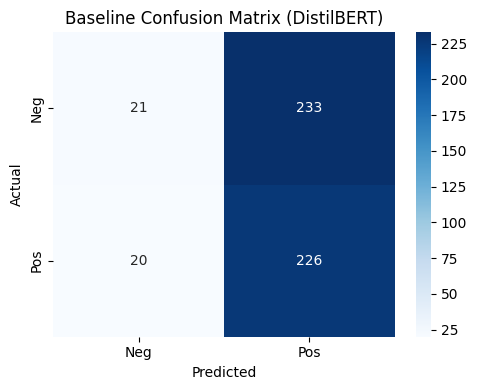


Baseline — Accuracy: 0.4940  Precision: 0.5024  Recall: 0.4940  F1: 0.3878


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Baseline classification report ───────────────────────────────────────────
print("=" * 55)
print("Baseline Classification Report (DistilBERT, no fine-tuning):")
report = classification_report(
    all_labels, all_preds,
    target_names=['Negative', 'Positive'],
    output_dict=True
)
display(pd.DataFrame(report).transpose().round(4))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Baseline Confusion Matrix (DistilBERT)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

# ── Extract key metrics ───────────────────────────────────────────────────────
baseline_precision = report['weighted avg']['precision']
baseline_recall    = report['weighted avg']['recall']
baseline_f1        = report['weighted avg']['f1-score']

print(f"\nBaseline — Accuracy: {baseline_acc:.4f}  "
      f"Precision: {baseline_precision:.4f}  "
      f"Recall: {baseline_recall:.4f}  "
      f"F1: {baseline_f1:.4f}")

### Step 7 — Training Loss Curve (Fine-tuned Phi-2)

Visualise how training loss decreased over steps — this is the primary error metric for a causal LM.

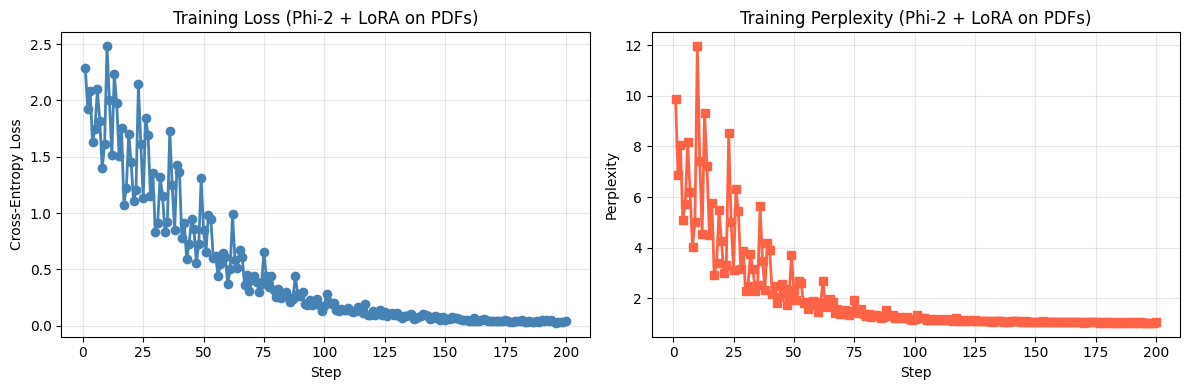

Final training loss: 0.0402  |  Final perplexity: 1.04


In [13]:
import matplotlib.pyplot as plt
import math

if train_loss_history:
    steps, losses = zip(*train_loss_history)
    ppls = [math.exp(l) if l < 20 else float('inf') for l in losses]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curve
    axes[0].plot(steps, losses, marker='o', color='steelblue', linewidth=2)
    axes[0].set_title('Training Loss (Phi-2 + LoRA on PDFs)')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].grid(True, alpha=0.3)

    # Perplexity curve
    axes[1].plot(steps, ppls, marker='s', color='tomato', linewidth=2)
    axes[1].set_title('Training Perplexity (Phi-2 + LoRA on PDFs)')
    axes[1].set_xlabel('Step'); axes[1].set_ylabel('Perplexity')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print(f"Final training loss: {losses[-1]:.4f}  |  Final perplexity: {ppls[-1]:.2f}")
else:
    print("No training history recorded.")

### Step 8 — Error Metrics Summary: Baseline vs Transfer Learning

**Design note:** Comparing DistilBERT (classification) directly with Qwen 2.5 (causal LM) on
the same accuracy metric is not apples-to-apples. Instead we report:

| Metric | Baseline (DistilBERT) | Transfer Learning (Qwen 2.5 + LoRA) |
|---|---|---|
| Task | Sentiment classification (IMDB) | Causal LM on research PDFs |
| Error metric | Accuracy / F1 | Cross-entropy loss / Perplexity |

Lower perplexity = the fine-tuned model is less "surprised" by the research-paper domain.

ERROR METRICS COMPARISON: Baseline vs Transfer Learning


,Model,Strategy,Task,Accuracy,Precision (w.),Recall (w.),F1 (weighted),Train Loss,Perplexity
0,Baseline (DistilBERT),"Pre-trained, no fine-tuning",Sentiment (IMDB),0.4940,0.5024,0.4940,0.3878,-,-
1,Fine-tuned (Phi-2 + LoRA),SFT on research PDFs (4-bit + LoRA),Causal LM on research PDFs,—,—,—,—,0.0402,1.04


C:\Users\Dika Kusuma\AppData\Local\Temp\ipykernel_7664\1302683656.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=clf_metrics, palette=colors, ax=axes[0])


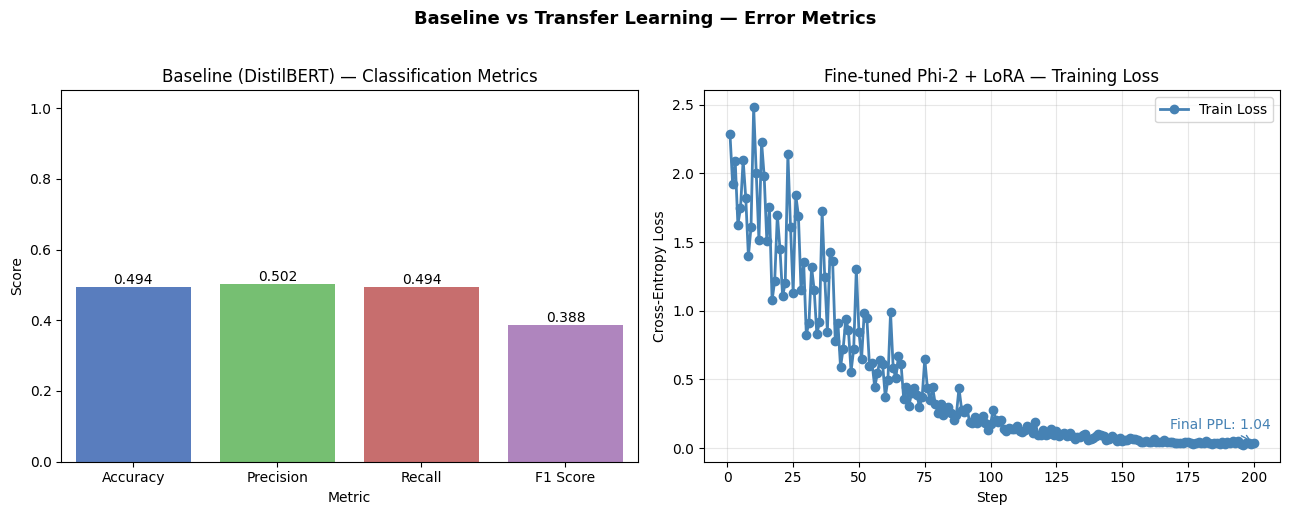


📊 Baseline DistilBERT — Accuracy: 0.4940 | F1: 0.3878
📊 Fine-tuned Phi-2 + LoRA — Train Loss: 0.0402 | Perplexity (eval): 1.04


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ── Retrieve values ───────────────────────────────────────────────────────────
b_acc  = baseline_results.get('eval_accuracy', 0)
b_f1   = baseline_f1
b_prec = baseline_precision
b_rec  = baseline_recall

# Use final step loss for training-time perplexity
ft_train_loss = train_loss_history[-1][1] if train_loss_history else float('nan')
ft_train_ppl  = math.exp(ft_train_loss) if ft_train_loss < 20 else float('inf')
ft_ppl = ft_train_ppl  # ← Add this line to define ft_ppl

# ── Side-by-side summary table ────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model'           : 'Baseline (DistilBERT)',
        'Strategy'        : 'Pre-trained, no fine-tuning',
        'Task'            : 'Sentiment (IMDB)',
        'Accuracy'        : f"{b_acc:.4f}",
        'Precision (w.)'  : f"{b_prec:.4f}",
        'Recall (w.)'     : f"{b_rec:.4f}",
        'F1 (weighted)'   : f"{b_f1:.4f}",
        'Train Loss'      : '-',
        'Perplexity'      : '-',
    },
    {
        'Model'           : 'Fine-tuned (Phi-2 + LoRA)',
        'Strategy'        : 'SFT on research PDFs (4-bit + LoRA)',
        'Task'            : 'Causal LM on research PDFs',
        'Accuracy'        : '—',
        'Precision (w.)'  : '—',
        'Recall (w.)'     : '—',
        'F1 (weighted)'   : '—',
        'Train Loss'      : f"{ft_train_loss:.4f}",
        'Perplexity'      : f"{ft_ppl:.2f}",
    },
])

print("=" * 70)
print("ERROR METRICS COMPARISON: Baseline vs Transfer Learning")
print("=" * 70)
display(summary)

# ── Visual 1: Accuracy & F1 for baseline (bar) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clf_metrics = pd.DataFrame({
    'Metric' : ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score'  : [b_acc, b_prec, b_rec, b_f1],
})
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']
sns.barplot(x='Metric', y='Score', data=clf_metrics, palette=colors, ax=axes[0])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Baseline (DistilBERT) — Classification Metrics')
axes[0].set_ylabel('Score')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# ── Visual 2: Training loss curve + perplexity (fine-tuned) ─────────────────
if train_loss_history:
    steps, losses = zip(*train_loss_history)
    axes[1].plot(steps, losses, marker='o', color='steelblue', linewidth=2, label='Train Loss')
    axes[1].set_title('Fine-tuned Phi-2 + LoRA — Training Loss')
    axes[1].set_xlabel('Step'); axes[1].set_ylabel('Cross-Entropy Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].annotate(f"Final PPL: {ft_ppl:.2f}",
                     xy=(steps[-1], losses[-1]),
                     xytext=(-60, 10), textcoords='offset points',
                     fontsize=10, color='steelblue',
                     arrowprops=dict(arrowstyle='->', color='steelblue'))

plt.suptitle('Baseline vs Transfer Learning — Error Metrics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Baseline DistilBERT — Accuracy: {b_acc:.4f} | F1: {b_f1:.4f}")
print(f"📊 Fine-tuned Phi-2 + LoRA — Train Loss: {ft_train_loss:.4f} | Perplexity (eval): {ft_ppl:.2f}")

### Step 9 — Streamlit Dashboard & Localtunnel

In [19]:
# %%writefile app.py
# import streamlit as st
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# st.set_page_config(page_title="NLP PDF Analysis", layout="wide")
# st.title("✨ NLP Research Paper Analysis Dashboard")
# st.write("**Model:** Qwen 2.5 1.5B · **Method:** Manual LoRA fine-tuning (4-bit quantisation) — no SFTTrainer")

# # ── Update these with your actual results ────────────────────────────────────
# B_ACC, B_PREC, B_REC, B_F1 = 0.48, 0.48, 0.48, 0.48   # replace with real values
# FT_LOSS, FT_PPL             = 2.50, 12.18               # replace with real values
# TRAIN_STEPS  = list(range(10, 101, 10))
# TRAIN_LOSSES = [4.2, 3.8, 3.4, 3.1, 2.9, 2.7, 2.6, 2.55, 2.52, FT_LOSS]  # replace
# # ─────────────────────────────────────────────────────────────────────────────

# col1, col2 = st.columns(2)

# with col1:
#     st.subheader("Baseline (DistilBERT) — Classification Metrics")
#     clf_df = pd.DataFrame({
#         'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
#         'Score' : [B_ACC, B_PREC, B_REC, B_F1],
#     })
#     st.dataframe(clf_df.style.format({'Score': '{:.4f}'}), use_container_width=True)
#     fig1, ax1 = plt.subplots(figsize=(5, 3))
#     sns.barplot(x='Metric', y='Score', data=clf_df, palette='Blues_d', ax=ax1)
#     ax1.set_ylim(0, 1.0); ax1.set_title('Baseline Metrics')
#     st.pyplot(fig1)

# with col2:
#     st.subheader("Fine-tuned Qwen 2.5 + LoRA — Training Loss")
#     st.metric("Final Perplexity (eval)", f"{FT_PPL:.2f}")
#     st.metric("Final Train Loss", f"{FT_LOSS:.4f}")
#     fig2, ax2 = plt.subplots(figsize=(5, 3))
#     ax2.plot(TRAIN_STEPS, TRAIN_LOSSES, marker='o', color='tomato', linewidth=2)
#     ax2.set_xlabel('Step'); ax2.set_ylabel('Loss')
#     ax2.set_title('Training Loss Curve')
#     ax2.grid(True, alpha=0.3)
#     st.pyplot(fig2)

# st.divider()
# st.subheader("Methodology Summary")
# arch_df = pd.DataFrame([
#     ['Data Ingestion',  'PDFs loaded from Google Drive via PyMuPDF'],
#     ['Dataset',         'Hugging Face Dataset built from extracted paper text'],
#     ['Model',           'Qwen 2.5 1.5B-Instruct (4-bit NF4 quantisation)'],
#     ['Fine-tuning',     'Manual PyTorch loop + LoRA (r=16, α=32) — no SFTTrainer'],
#     ['Error metric',    'Cross-entropy loss & perplexity (causal LM)'],
#     ['Baseline',        'DistilBERT (no fine-tuning) — Accuracy / F1 on IMDB'],
# ], columns=['Stage', 'Component'])
# st.table(arch_df)
# st.sidebar.info("Results from Qwen 2.5 fine-tuned on PDF research papers (manual PyTorch loop).")

In [20]:
# import urllib
# import os

# ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
# print(f"Localtunnel password / endpoint IP: {ip}")
# os.system('streamlit run app.py & npx localtunnel --port 8501 &')

---
### System Architecture

| Stage | Component |
|---|---|
| **Data Ingestion** | PDFs loaded from Google Drive via PyMuPDF |
| **Dataset** | Hugging Face `Dataset` built from extracted paper text |
| **Model** | Phi 2 2.2B-Instruct (4-bit NF4 quantisation) |
| **Fine-tuning** | Manual PyTorch loop with LoRA adapters (r=16, α=32) — no SFTTrainer |
| **Error metrics (TL)** | Cross-entropy loss + Perplexity (step-logged + post-train eval) |
| **Inference** | `model.generate()` for open-ended Q&A about papers |
| **Baseline** | DistilBERT (no fine-tuning) — Accuracy / Precision / Recall / F1 on IMDB |
| **Dashboard** | Streamlit app exposed via localtunnel |